# Final Lane Counting Notebook

This notebook keeps **manual lane boundary selection** as the source of truth, but shows **auto-detected lane guides** from the lane detection pipeline to help the user place points more accurately.

In [1]:
import os
os.environ.setdefault('QT_QPA_FONTDIR', '/usr/share/fonts/truetype/dejavu')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression

MODEL_WEIGHTS = 'yolov8n.pt'
model = YOLO(MODEL_WEIGHTS)
model.to('cpu')

print('Model loaded:', MODEL_WEIGHTS)

Model loaded: yolov8n.pt


In [2]:
def show_bgr(image, title, size=(12, 7)):
    plt.figure(figsize=size)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


def detect_auto_lane_guides(img):
    h, w = img.shape[:2]

    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
    white_mask = cv2.inRange(hls, np.array([0, 190, 0]), np.array([180, 255, 255]))
    yellow_mask = cv2.inRange(hls, np.array([15, 40, 100]), np.array([35, 255, 255]))
    mask = cv2.bitwise_or(white_mask, yellow_mask)

    edges = cv2.Canny(mask, 50, 150)
    roi_poly = np.array([[(0, h), (w, h), (int(w * 0.8), int(h * 0.1)), (int(w * 0.4), int(h * 0.1))]], np.int32)
    roi_mask = np.zeros_like(edges)
    cv2.fillPoly(roi_mask, roi_poly, 255)
    masked_edges = cv2.bitwise_and(edges, roi_mask)

    lines = cv2.HoughLinesP(masked_edges, 1, np.pi / 180, 30, minLineLength=30, maxLineGap=200)

    features = []
    segments = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 == x2:
                continue
            m = (y2 - y1) / (x2 - x1)
            if abs(m) < 0.35:
                continue
            b = y1 - m * x1
            x_bottom = (h - b) / m
            theta = np.arctan(m)
            features.append([x_bottom / w, theta])
            segments.append((x1, y1, x2, y2))

    guides = []
    if features:
        labels = DBSCAN(eps=0.05, min_samples=1).fit_predict(features)
        for cluster_id in sorted(set(labels)):
            indices = np.where(labels == cluster_id)[0]
            pts = []
            for idx in indices:
                x1, y1, x2, y2 = segments[idx]
                pts.extend([(x1, y1), (x2, y2)])
            pts = np.array(pts)
            X = pts[:, 1].reshape(-1, 1)
            y = pts[:, 0]
            lr = LinearRegression().fit(X, y)
            y_range = np.array([h, int(h * 0.1)], dtype=np.int32)
            x_preds = np.asarray(lr.predict(y_range.reshape(-1, 1))).ravel()
            pt1 = (int(x_preds[0]), int(y_range[0]))
            pt2 = (int(x_preds[1]), int(y_range[1]))
            guides.append((pt1, pt2))

    return guides, roi_poly

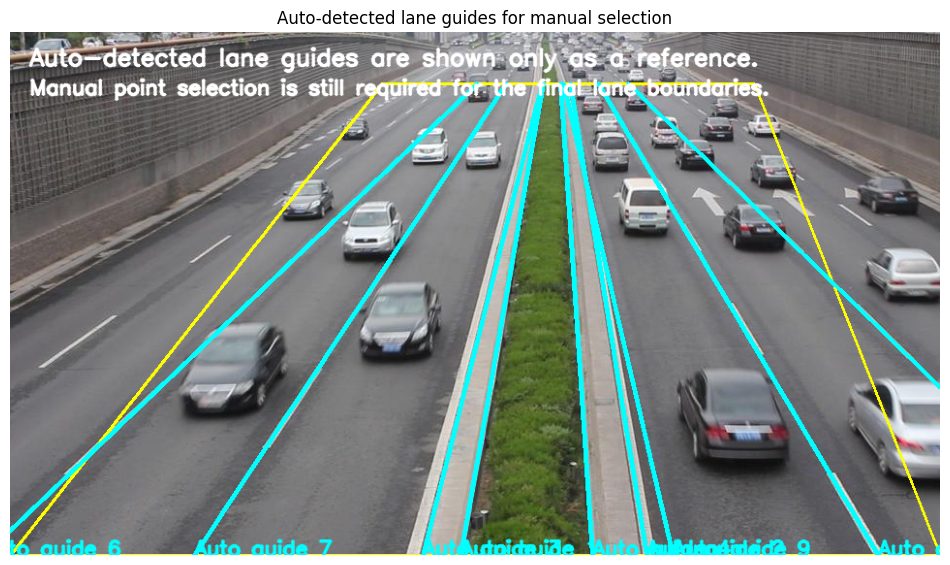

In [3]:
image_path = 'dataset/best/img00001.jpg'
ref_frame = cv2.imread(image_path)
if ref_frame is None:
    raise FileNotFoundError(f'Image not found: {image_path}')

auto_guides, roi_poly = detect_auto_lane_guides(ref_frame)
preview = ref_frame.copy()

cv2.polylines(preview, roi_poly, isClosed=True, color=(0, 255, 255), thickness=2)
for i, (pt1, pt2) in enumerate(auto_guides, start=1):
    cv2.line(preview, pt1, pt2, (255, 255, 0), 3)
    cv2.putText(preview, f'Auto guide {i}', pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2, cv2.LINE_AA)

cv2.putText(
    preview,
    'Auto-detected lane guides are shown only as a reference.',
    (20, 35),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)
cv2.putText(
    preview,
    'Manual point selection is still required for the final lane boundaries.',
    (20, 65),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

show_bgr(preview, 'Auto-detected lane guides for manual selection')

In [4]:
NUM_LANES = 3
lane_names = [f'Lane_{i + 1}' for i in range(NUM_LANES)]
lane_points = {name: [] for name in lane_names}
current_lane_idx = 0
window_name = 'Manual Lane Selection | Auto guides are only visual help'


def redraw_lane_canvas():
    canvas = ref_frame.copy()

    for i, (pt1, pt2) in enumerate(auto_guides, start=1):
        cv2.line(canvas, pt1, pt2, (255, 255, 0), 3)
        cv2.putText(canvas, f'Auto guide {i}', pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 0), 2, cv2.LINE_AA)

    for i, name in enumerate(lane_names):
        pts = lane_points[name]
        if not pts:
            continue

        pts_np = np.array(pts, np.int32)
        is_active = i == current_lane_idx
        is_finished = i < current_lane_idx

        if len(pts) >= 2:
            if len(pts) >= 3:
                cv2.polylines(
                    canvas,
                    [pts_np],
                    isClosed=True,
                    color=(0, 255, 0) if (is_finished or not is_active) else (0, 255, 255),
                    thickness=3,
                )
            else:
                cv2.polylines(
                    canvas,
                    [pts_np],
                    isClosed=False,
                    color=(0, 200, 255),
                    thickness=2,
                )

        for p in pts:
            cv2.circle(canvas, p, 4, (0, 0, 255), -1)

        label_x = min(max(pts[0][0] + 8, 10), ref_frame.shape[1] - 150)
        label_y = min(max(pts[0][1] - 8, 20), ref_frame.shape[0] - 10)
        cv2.putText(canvas, name, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

    if current_lane_idx < len(lane_names):
        active = lane_names[current_lane_idx]
        status = f'Marking: {active} ({len(lane_points[active])} points)'
    else:
        status = 'All lanes marked. Press q to finish or b to review previous lane.'

    cv2.putText(canvas, status, (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(
        canvas,
        'Auto guides are for reference only | Click to add points | z undo | r reset lane | b back | n next lane | q finish',
        (20, 65),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return canvas


def on_mouse(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and current_lane_idx < len(lane_names):
        lane_points[lane_names[current_lane_idx]].append((x, y))


cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.setMouseCallback(window_name, on_mouse)
cv2.resizeWindow(window_name, ref_frame.shape[1], ref_frame.shape[0])
cv2.setWindowProperty(window_name, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

while True:
    cv2.imshow(window_name, redraw_lane_canvas())
    key = cv2.waitKey(20) & 0xFF

    if key == ord('z') and current_lane_idx < len(lane_names):
        if lane_points[lane_names[current_lane_idx]]:
            lane_points[lane_names[current_lane_idx]].pop()

    elif key == ord('r') and current_lane_idx < len(lane_names):
        lane_points[lane_names[current_lane_idx]] = []

    elif key == ord('b') and current_lane_idx > 0:
        current_lane_idx -= 1

    elif key == ord('n') and current_lane_idx < len(lane_names):
        lane_name = lane_names[current_lane_idx]
        if len(lane_points[lane_name]) >= 3:
            current_lane_idx += 1
            if current_lane_idx >= len(lane_names):
                print('All lanes marked. Press q to finish.')
        else:
            print(f'{lane_name}: add at least 3 points before next lane')

    elif key == ord('q'):
        break

cv2.destroyAllWindows()

lane_polygons = {name: np.array(points, np.int32) for name, points in lane_points.items()}
print('lane_polygons = {')
for name, poly in lane_polygons.items():
    print(f'    "{name}": np.array({poly.tolist()}, np.int32),')
print('}')

QFontDatabase: Cannot find font directory /home/muditha/VisionProject/cv_project/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/muditha/VisionProject/cv_project/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/muditha/VisionProject/cv_project/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/muditha/VisionProject/cv_project/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDat

All lanes marked. Press q to finish.
lane_polygons = {
    "Lane_1": np.array([[80, 434], [248, 453], [487, 94], [445, 87]], np.int32),
    "Lane_2": np.array([[250, 454], [444, 457], [531, 97], [487, 94]], np.int32),
    "Lane_3": np.array([[646, 461], [836, 441], [628, 87], [582, 88]], np.int32),
}


In [5]:
def draw_lanes(frame):
    for name, poly in lane_polygons.items():
        if len(poly) >= 2:
            cv2.polylines(frame, [poly], isClosed=True, color=(0, 255, 0), thickness=2)
        if len(poly) >= 1:
            cv2.putText(frame, name, tuple(poly[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    return frame


def get_vehicle_anchor(x1, y1, x2, y2):
    return (x1 + x2) // 2, y2


def detect_vehicles_in_polygon(frame, poly, model, conf=0.25, imgsz=640, vehicle_classes={2, 3, 5, 7}, padding=20):
    x, y, w, h = cv2.boundingRect(poly)
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(frame.shape[1], x + w + padding)
    y2 = min(frame.shape[0], y + h + padding)
    roi = frame[y1:y2, x1:x2].copy()
    if roi.size == 0 or roi.shape[0] < 16 or roi.shape[1] < 16:
        return []

    results = model(roi, conf=conf, imgsz=imgsz, verbose=False, device='cpu')
    detections = []
    for result in results:
        for box in result.boxes:
            cls = int(box.cls[0])
            if cls not in vehicle_classes:
                continue

            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            gx1, gy1 = bx1 + x1, by1 + y1
            gx2, gy2 = bx2 + x1, by2 + y1
            cx, cy = get_vehicle_anchor(gx1, gy1, gx2, gy2)

            if cv2.pointPolygonTest(poly, (cx, cy), False) >= 0:
                detections.append({
                    'bbox': (gx1, gy1, gx2, gy2),
                    'anchor': (cx, cy),
                    'conf': float(box.conf[0]),
                    'cls': cls,
                })
    return detections

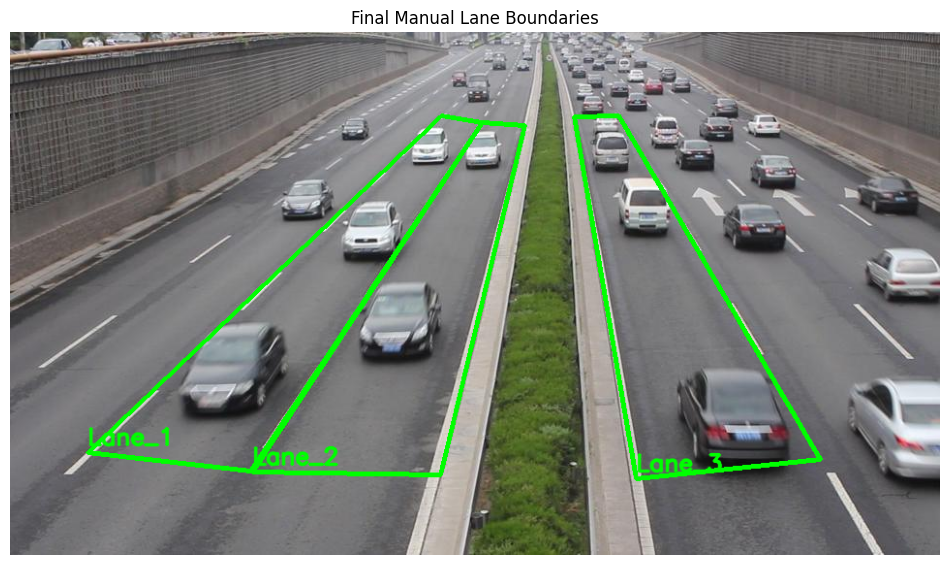

In [6]:
show_frame = cv2.imread('dataset/best/img00001.jpg')
if show_frame is None:
    raise FileNotFoundError('dataset/best/img00001.jpg not found')

if 'lane_polygons' not in globals() or not lane_polygons:
    raise ValueError('lane_polygons is empty. Run the manual selection cell first.')

marked = show_frame.copy()
for lane_name, poly in lane_polygons.items():
    if len(poly) >= 2:
        cv2.polylines(marked, [poly], isClosed=True, color=(0, 255, 0), thickness=3)
    if len(poly) >= 1:
        x, y = poly[0]
        cv2.putText(marked, lane_name, (int(x), int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)

show_bgr(marked, 'Final Manual Lane Boundaries')

Vehicle Counts: {'Lane_1': 4, 'Lane_2': 2, 'Lane_3': 4}


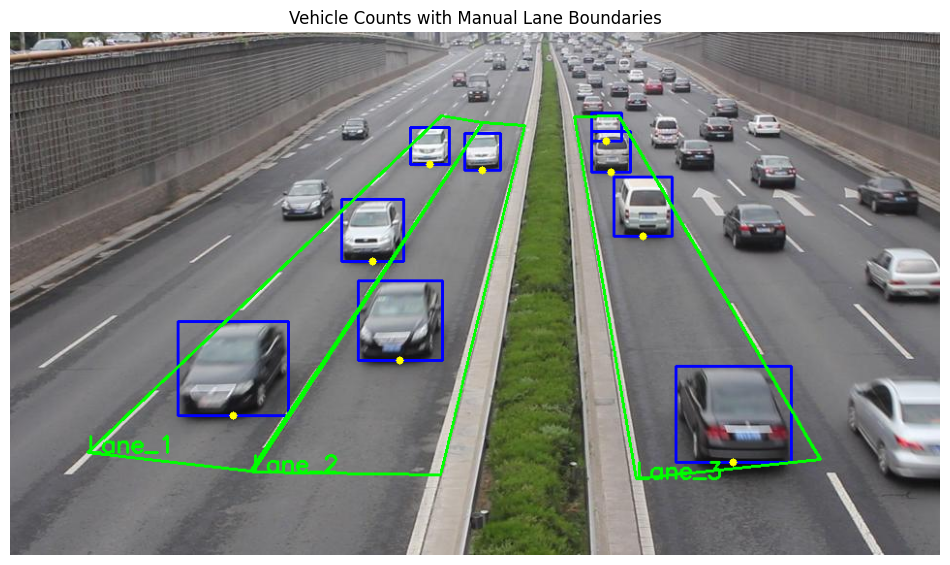

In [7]:
image_path = 'dataset/best/img00001.jpg'
frame = cv2.imread(image_path)
if frame is None:
    raise FileNotFoundError(f'{image_path} not found')

counts = {name: 0 for name in lane_polygons}
vehicle_classes = {2, 3, 5, 7}
conf_threshold = 0.25

for lane_name, poly in lane_polygons.items():
    detections = detect_vehicles_in_polygon(
        frame,
        poly,
        model,
        conf=conf_threshold,
        imgsz=640,
        vehicle_classes=vehicle_classes,
    )
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        counts[lane_name] += 1
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cx, cy = det['anchor']
        cv2.circle(frame, (cx, cy), 4, (0, 255, 255), -1)

frame = draw_lanes(frame)
print(f'Vehicle Counts: {counts}')
show_bgr(frame, 'Vehicle Counts with Manual Lane Boundaries')

In [15]:
from pathlib import Path
import numpy as np
import cv2

conf_threshold = 0.3

# Prerequisite: lane_polygons should already be created from the lane marking step
if "lane_polygons" not in globals() or not lane_polygons:
    raise ValueError("lane_polygons is empty. Run lane extraction cells first.")

# Load YOLO model if not already available in notebook state
if "model" not in globals():
    from ultralytics import YOLO
    MODEL_WEIGHTS = "yolov8s.pt"
    model = YOLO(MODEL_WEIGHTS)


def detect_vehicles_all_lanes_once(
    frame,
    lane_polygons,
    model,
    conf=0.25,
    imgsz=640,
    vehicle_classes={2, 3, 5, 7},
    padding=20,
):
    valid_polys = [poly for poly in lane_polygons.values() if len(poly) >= 3]
    if not valid_polys:
        return [], {name: [] for name in lane_polygons}

    merged_points = np.vstack(valid_polys).astype(np.int32)
    x, y, w, h = cv2.boundingRect(merged_points)
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(frame.shape[1], x + w + padding)
    y2 = min(frame.shape[0], y + h + padding)

    roi = frame[y1:y2, x1:x2].copy()
    results = model(roi, conf=conf, imgsz=imgsz, verbose=False)

    all_detections = []
    detections_by_lane = {name: [] for name in lane_polygons}

    for result in results:
        for box in result.boxes:
            cls = int(box.cls[0])
            if cls not in vehicle_classes:
                continue

            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            gx1, gy1 = bx1 + x1, by1 + y1
            gx2, gy2 = bx2 + x1, by2 + y1
            cx, cy = (gx1 + gx2) // 2, gy2

            best_lane = None
            best_score = -1.0

            for lane_name, poly in lane_polygons.items():
                if len(poly) < 3:
                    continue
                score = cv2.pointPolygonTest(poly, (cx, cy), True)
                if score >= 0 and score > best_score:
                    best_score = score
                    best_lane = lane_name

            if best_lane is None:
                continue

            det = {
                "bbox": (gx1, gy1, gx2, gy2),
                "anchor": (cx, cy),
                "conf": float(box.conf[0]),
                "cls": cls,
                "lane": best_lane,
            }

            all_detections.append(det)
            detections_by_lane[best_lane].append(det)

    return all_detections, detections_by_lane


# Change this if your images are in a different folder
dataset_dir = Path("dataset/best")

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
image_paths = sorted(
    [p for p in dataset_dir.rglob("*") if p.suffix.lower() in valid_exts]
)

if not image_paths:
    print(f"No images found in: {dataset_dir.resolve()}")
else:
    vehicle_classes = {2, 3, 5, 7}  # car, motorcycle, bus, truck

    index = 0
    needs_redraw = True
    window_name = "Dataset Viewer: Final Vehicle Count View (A/Left, D/Right, Q/Esc)"

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.setWindowProperty(window_name, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

    if hasattr(cv2, "WND_PROP_TOPMOST"):
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)

    while True:
        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
            break

        if needs_redraw:
            img_path = image_paths[index]
            img = cv2.imread(str(img_path))

            if img is None:
                display_img = 255 * np.ones((220, 1100, 3), dtype=np.uint8)
                cv2.putText(display_img, f"Failed to load: {img_path}", (20, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            else:
                display_img = img.copy()
                counts = {name: 0 for name in lane_polygons}

                all_detections, detections_by_lane = detect_vehicles_all_lanes_once(
                    display_img,
                    lane_polygons,
                    model,
                    conf=conf_threshold,
                    imgsz=640,
                    vehicle_classes=vehicle_classes,
                    padding=20,
                )

                for lane_name, lane_dets in detections_by_lane.items():
                    counts[lane_name] = len(lane_dets)

                for det in all_detections:
                    x1, y1, x2, y2 = det["bbox"]
                    cx, cy = det["anchor"]
                    lane_name = det["lane"]

                    cv2.rectangle(display_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.circle(display_img, (cx, cy), 4, (0, 255, 255), -1)
                    cv2.putText(display_img, lane_name, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

                # Draw lane boundaries
                for lane_name, poly in lane_polygons.items():
                    if len(poly) >= 2:
                        cv2.polylines(display_img, [poly], isClosed=True, color=(0, 255, 0), thickness=2)
                    if len(poly) >= 1:
                        x, y = poly[0]
                        cv2.putText(display_img, lane_name, (int(x), int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

                # Draw per-lane counts
                y0 = 62
                for lane_name in lane_polygons.keys():
                    cv2.putText(display_img, f"{lane_name}: {counts[lane_name]}", (20, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 255), 2)
                    y0 += 30

            status_text = f"{index + 1}/{len(image_paths)}  |  {img_path}"
            cv2.putText(display_img, status_text, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

            cv2.imshow(window_name, display_img)
            needs_redraw = False

        key = cv2.waitKey(30) & 0xFF

        if key in [ord("d"), 83]:
            index = (index + 1) % len(image_paths)
            needs_redraw = True
        elif key in [ord("a"), 81]:
            index = (index - 1) % len(image_paths)
            needs_redraw = True
        elif key in [ord("q"), 27]:
            break

    cv2.destroyAllWindows()